#1B Segmentación

En este notebook para mejorar la segmentación del área de interés, se probó con un modelo preentrenado de segmentación anatómica (TorchXRayVision, PSPNet entrenado en ChestX-Det)  

## 1.1 Importar librerías

In [ ]:
!pip install torchxrayvision torch torchvision scikit-image --quiet

In [ ]:
import os
import torch
import torchvision
import torchxrayvision as xrv
import numpy as np
from skimage.io import imread
from glob import glob
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import shutil
import cv2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [ ]:
#Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##1.2 Cargar el modelo de segmentación

In [ ]:
# Modelo de segmentación anatómica (PSPNet sobre ChestX-Det)
seg_model = xrv.baseline_models.chestx_det.PSPNet().to(DEVICE)
seg_model.eval()

print("Targets del modelo:", seg_model.targets)
# Deben incluir: 'Left Lung', 'Right Lung'

Targets del modelo: ['Left Clavicle', 'Right Clavicle', 'Left Scapula', 'Right Scapula', 'Left Lung', 'Right Lung', 'Left Hilus Pulmonis', 'Right Hilus Pulmonis', 'Heart', 'Aorta', 'Facies Diaphragmatica', 'Mediastinum', 'Weasand', 'Spine']


In [ ]:
# Transformaciones estándar de TorchXRayVision
transform = torchvision.transforms.Compose([
    xrv.datasets.XRayCenterCrop(),
    xrv.datasets.XRayResizer(512)
])

def segment_lungs_xrv_from_path(img_path, thresh=0.5):
    # 1. Leer imagen (RGB o escala de grises)
    img = imread(img_path)  # skimage lee como uint8 [0,255]

    # 2. Normalizar a rango esperado [-1024, 1024]
    img = xrv.datasets.normalize(img, 255)

    # 3. Convertir a 1 canal si viene RGB
    if img.ndim == 3:
        img = img.mean(2)

    # 4. Añadir dimensión canal
    img_np = img[None, ...]   # (1, H, W)

    # 5. Centro + resize a 512x512
    img_np = transform(img_np)  # sigue siendo numpy

    # 6. A tensor y batch
    img_t = torch.from_numpy(img_np).float().to(DEVICE)  # (1, 512, 512)
    img_t = img_t.unsqueeze(0)  # (B=1, C=1, 512, 512)

    with torch.no_grad():
        out = seg_model(img_t)  # (1, 14, 512, 512)

    out = out[0]  # (14, 512, 512)

    # Índices de pulmones en los canales de salida
    left_idx  = seg_model.targets.index("Left Lung")
    right_idx = seg_model.targets.index("Right Lung")

    lung_logits = torch.stack([out[left_idx], out[right_idx]], dim=0)  # (2, 512, 512)
    lung_prob = torch.sigmoid(lung_logits)  # convertir a probabilidad

    # Máscara binaria combinando ambos pulmones
    lung_mask = (lung_prob > thresh).any(dim=0).cpu().numpy().astype(np.uint8) * 255

    # Imagen preprocesada (512x512) para visualizar
    img_vis = img_np[0]  # (512, 512)

    return img_vis, lung_mask

##1.3 Se carga la ruta del dataset preprocesado

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/chest_xray_preprocessed"
train_normal = glob(os.path.join(DATASET_PATH, "train/NORMAL/*.jpeg"))
train_pneu   = glob(os.path.join(DATASET_PATH, "train/PNEUMONIA/*.jpeg"))

print("NORMAL train:", len(train_normal))
print("PNEUMONIA train:", len(train_pneu))


NORMAL train: 1341
PNEUMONIA train: 3875


In [ ]:
#Ruta de salida

OUTPUT_PATH = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/masks"

# Crear carpeta raíz
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

# Crear carpetas espejo al dataset original
subsets = ["train", "test", "val"]
classes = ["NORMAL", "PNEUMONIA"]

for subset in subsets:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_PATH, subset, cls), exist_ok=True)

Ejemplo NORMAL:


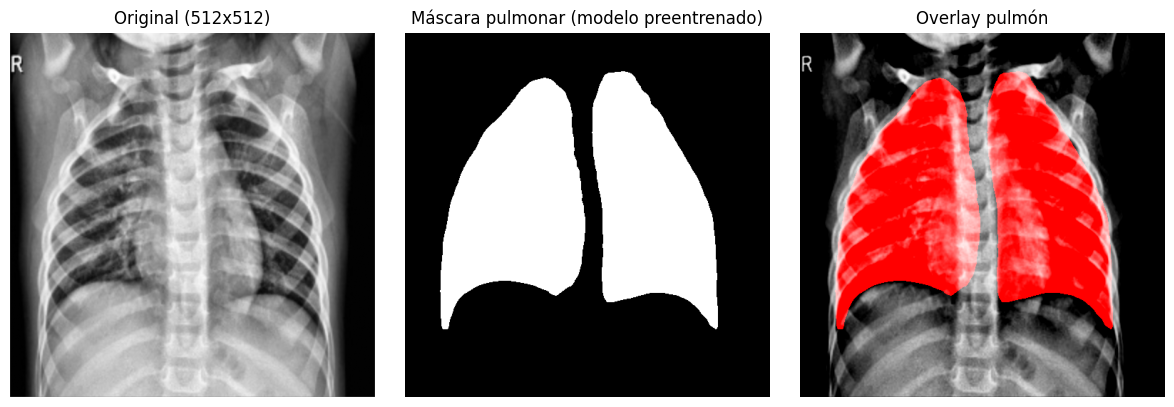

Ejemplo PNEUMONIA:


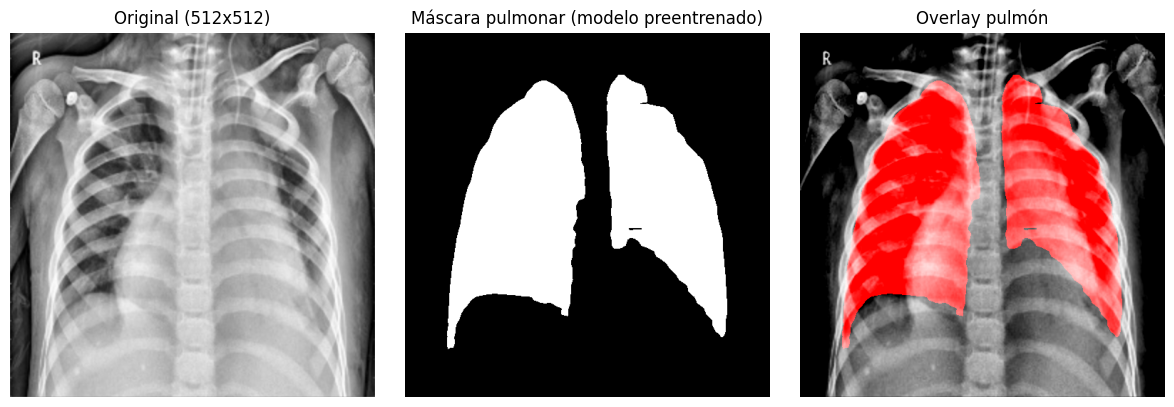

In [ ]:
#Visualizar un ejemplo de cada clase

def show_seg_example(img_path):
    img_vis, lung_mask = segment_lungs_xrv_from_path(img_path, thresh=0.5)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_vis, cmap='gray')
    plt.title("Original (512x512)")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(lung_mask, cmap='gray')
    plt.title("Máscara pulmonar (modelo preentrenado)")
    plt.axis('off')

    # Overlay en rojo
    overlay = np.dstack([
        img_vis / img_vis.max(),
        img_vis / img_vis.max(),
        img_vis / img_vis.max()
    ])
    mask_bool = lung_mask > 0
    overlay[mask_bool, 0] = 1.0  # canal rojo

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Overlay pulmón")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

print("Ejemplo NORMAL:")
show_seg_example(random.choice(train_normal))

print("Ejemplo PNEUMONIA:")
show_seg_example(random.choice(train_pneu))

##1.4 Se crea el dataset de las máscaras

In [ ]:
for subset in subsets:
    for cls in classes:

        in_dir  = os.path.join(DATASET_PATH, subset, cls)
        out_dir = os.path.join(OUTPUT_PATH, subset, cls)

        img_paths = glob(os.path.join(in_dir, "*.jpeg"))

        print(f"Procesando {subset}/{cls}: {len(img_paths)} imágenes")

        for p in tqdm(img_paths, desc=f"{subset}/{cls}"):

            try:
                # Segmentación con modelo preentrenado
                _, lung_mask = segment_lungs_xrv_from_path(p, thresh=0.5)

                # Ruta de salida
                fname = os.path.basename(p)
                out_path = os.path.join(out_dir, fname)

                # Guardar la máscara
                cv2.imwrite(out_path, lung_mask)

            except Exception as e:
                print("Error en:", p, "->", e)
                continue


Procesando train/NORMAL: 1341 imágenes


train/NORMAL: 100%|██████████| 1341/1341 [04:28<00:00,  4.99it/s]


Procesando train/PNEUMONIA: 3875 imágenes


train/PNEUMONIA: 100%|██████████| 3875/3875 [12:51<00:00,  5.02it/s]


Procesando test/NORMAL: 234 imágenes


...

test/PNEUMONIA: 100%|██████████| 390/390 [01:15<00:00,  5.17it/s]


Procesando val/NORMAL: 8 imágenes


val/NORMAL: 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]


Procesando val/PNEUMONIA: 8 imágenes


val/PNEUMONIA: 100%|██████████| 8/8 [00:02<00:00,  2.87it/s]
